In [1]:
# ============================================================
# CELL 1: IMPORTS
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import f_regression
import seaborn as sns

print("All imports successful!")

C:\Users\Abdul\AppData\Local\Temp\ipykernel_24244\2823460987.py:8: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


All imports successful!


In [2]:
# ============================================================
# CELL 2: SET UP PATHS USING EXISTING leaf_dataset
# ============================================================

import os

# Path to your already-split dataset
DATASET_PATH = 'data/leaf_dataset'

# Training paths
TRAIN_N_PATH = os.path.join(DATASET_PATH, 'train', 'nitrogen')
TRAIN_P_PATH = os.path.join(DATASET_PATH, 'train', 'phosphorus')
TRAIN_K_PATH = os.path.join(DATASET_PATH, 'train', 'potassium')

# Testing paths
TEST_N_PATH = os.path.join(DATASET_PATH, 'test', 'nitrogen')
TEST_P_PATH = os.path.join(DATASET_PATH, 'test', 'phosphorus')
TEST_K_PATH = os.path.join(DATASET_PATH, 'test', 'potassium')

# Helper function to count images
def count_images(path):
    if os.path.exists(path):
        return len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    return 0

# Count training images
train_n = count_images(TRAIN_N_PATH)
train_p = count_images(TRAIN_P_PATH)
train_k = count_images(TRAIN_K_PATH)

# Count testing images
test_n = count_images(TEST_N_PATH)
test_p = count_images(TEST_P_PATH)
test_k = count_images(TEST_K_PATH)

print("TRAINING IMAGES:")
print(f"  Nitrogen: {train_n}")
print(f"  Phosphorus: {train_p}")
print(f"  Potassium: {train_k}")
print(f"  Total training: {train_n + train_p + train_k}")

print("\nTESTING IMAGES:")
print(f"  Nitrogen: {test_n}")
print(f"  Phosphorus: {test_p}")
print(f"  Potassium: {test_k}")
print(f"  Total testing: {test_n + test_p + test_k}")

# Verify paths
print(f"\nTRAIN_N_PATH exists: {os.path.exists(TRAIN_N_PATH)}")
print(f"TRAIN_P_PATH exists: {os.path.exists(TRAIN_P_PATH)}")
print(f"TRAIN_K_PATH exists: {os.path.exists(TRAIN_K_PATH)}")

TRAINING IMAGES:
  Nitrogen: 352
  Phosphorus: 266
  Potassium: 306
  Total training: 924

TESTING IMAGES:
  Nitrogen: 88
  Phosphorus: 67
  Potassium: 77
  Total testing: 232

TRAIN_N_PATH exists: True
TRAIN_P_PATH exists: True
TRAIN_K_PATH exists: True


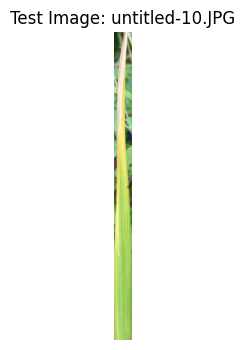

Image shape: (3313, 184, 3) (Height, Width, Channels)
Pixel value range: 0 to 255


In [4]:
# ============================================================
# CELL 3: TEST LOADING ONE IMAGE
# ============================================================

import cv2
import matplotlib.pyplot as plt

# Get first nitrogen training image
n_files = [f for f in os.listdir(TRAIN_N_PATH) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
test_img_path = os.path.join(TRAIN_N_PATH, n_files[0])

# Load image
img = cv2.imread(test_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(6, 4))
plt.imshow(img_rgb)
plt.title(f"Test Image: {n_files[0]}")
plt.axis('off')
plt.show()

print(f"Image shape: {img.shape} (Height, Width, Channels)")
print(f"Pixel value range: {img.min()} to {img.max()}")

In [17]:
# ============================================================
# CELL 4 (IMPROVED): FEATURE EXTRACTION - COLOR FEATURES
# ============================================================

import numpy as np

def extract_color_features(img_rgb):
    """
    Extract improved color-based features from the image.
    """
    features = {}
    
    img_float = img_rgb.astype(float)
    
    R = img_float[:, :, 0]
    G = img_float[:, :, 1]
    B = img_float[:, :, 2]
    
    total_pixels = R.size
    
    # Feature 1: Mean Green Intensity
    features['mean_green'] = np.mean(G)
    
    # Feature 2: Yellow Percentage (IMPROVED)
    yellow_mask = (R > 120) & (G > 120) & (B < 90) & (R > B + 30) & (G > B + 30)
    features['yellow_percentage'] = (np.sum(yellow_mask) / total_pixels) * 100
    
    # Feature 3: Mean Red Intensity
    features['mean_red'] = np.mean(R)
    
    # Feature 4: Purple Tint Score (IMPROVED - normalized)
    purple_mask = (R > G + 10) & (R > B)
    if np.sum(purple_mask) > 0:
        features['purple_tint'] = np.mean((R[purple_mask] - G[purple_mask]) / (R[purple_mask] + G[purple_mask] + 1)) * 100
    else:
        features['purple_tint'] = 0
    
    # Feature 5: Brown Percentage (IMPROVED)
    brown_mask = (R > 70) & (R < 160) & (G > 40) & (G < 110) & (B > 10) & (B < 70) & (R > G) & (G > B)
    features['brown_percentage'] = (np.sum(brown_mask) / total_pixels) * 100
    
    # Feature 6: Green-to-Yellow Ratio (IMPROVED green detection)
    green_mask = (G > R) & (G > B) & (G > 100)
    green_pixels = np.sum(green_mask)
    yellow_pixels = np.sum(yellow_mask)
    features['green_yellow_ratio'] = green_pixels / (yellow_pixels + 1)
    
    # Feature 7: Color Variance
    features['color_variance'] = np.std(G)
    
    # Feature 8: Red-to-Green Ratio (NEW - important for P deficiency)
    features['red_green_ratio'] = np.mean(R) / (np.mean(G) + 1)
    
    # Feature 9: Yellow Uniformity (NEW - distinguishes N from senescence)
    if yellow_pixels > 0:
        yellow_R = R[yellow_mask]
        yellow_G = G[yellow_mask]
        features['yellow_uniformity'] = 1.0 / (np.std(yellow_R) + np.std(yellow_G) + 1)
    else:
        features['yellow_uniformity'] = 0
    
    return features

# Test on the same image
test_color_improved = extract_color_features(img_rgb)
print("Improved Color Features:")
for name, value in test_color_improved.items():
    print(f"  {name}: {value:.2f}")

Improved Color Features:
  mean_green: 193.15
  yellow_percentage: 11.01
  mean_red: 167.24
  purple_tint: 4.44
  brown_percentage: 0.50
  green_yellow_ratio: 6.38
  color_variance: 46.66
  red_green_ratio: 0.86
  yellow_uniformity: 0.03


In [18]:
# ============================================================
# CELL 5: FEATURE EXTRACTION - SPATIAL PATTERNS
# ============================================================

def extract_spatial_features(img_rgb):
    """
    Extract features based on WHERE symptoms appear.
    """
    features = {}
    
    img_float = img_rgb.astype(float)
    R = img_float[:, :, 0]
    G = img_float[:, :, 1]
    B = img_float[:, :, 2]
    
    h, w = R.shape
    
    # Define regions
    tip_region_h = h // 5
    middle_start = h // 5
    middle_end = 4 * h // 5
    base_start = 4 * h // 5
    
    margin_width = w // 10
    
    # Feature 8: Tip Yellowing Score
    tip_R = R[:tip_region_h, :]
    tip_G = G[:tip_region_h, :]
    tip_B = B[:tip_region_h, :]
    tip_yellow = np.sum((tip_R > 150) & (tip_G > 150) & (tip_B < 100))
    tip_total = tip_R.size
    features['tip_yellowing'] = tip_yellow / tip_total if tip_total > 0 else 0
    
    # Feature 9: Margin Browning Score
    left_margin_R = R[:, :margin_width]
    left_margin_G = G[:, :margin_width]
    left_margin_B = B[:, :margin_width]
    right_margin_R = R[:, -margin_width:]
    right_margin_G = G[:, -margin_width:]
    right_margin_B = B[:, -margin_width:]
    
    brown_left = np.sum((left_margin_R > 80) & (left_margin_R < 150) & 
                         (left_margin_G > 40) & (left_margin_G < 100) & 
                         (left_margin_B > 10) & (left_margin_B < 60))
    brown_right = np.sum((right_margin_R > 80) & (right_margin_R < 150) & 
                          (right_margin_G > 40) & (right_margin_G < 100) & 
                          (right_margin_B > 10) & (right_margin_B < 60))
    
    margin_total = left_margin_R.size + right_margin_R.size
    features['margin_browning'] = (brown_left + brown_right) / margin_total if margin_total > 0 else 0
    
    # Feature 10: V-Shape Gradient
    middle_R = R[middle_start:middle_end, :]
    middle_G = G[middle_start:middle_end, :]
    middle_B = B[middle_start:middle_end, :]
    middle_yellow = np.sum((middle_R > 150) & (middle_G > 150) & (middle_B < 100))
    middle_total = middle_R.size
    middle_yellow_val = middle_yellow / middle_total if middle_total > 0 else 0
    features['v_shape_gradient'] = features['tip_yellowing'] - middle_yellow_val
    
    # Feature 11: Basal Green Retention
    base_G = G[base_start:, :]
    base_R = R[base_start:, :]
    base_green = np.sum((base_G > 100) & (base_R < 150))
    base_total = base_G.size
    features['basal_green'] = base_green / base_total if base_total > 0 else 0
    
    # Feature 12: Tip-to-Base Yellow Ratio
    base_R = R[base_start:, :]
    base_G = G[base_start:, :]
    base_B = B[base_start:, :]
    base_yellow = np.sum((base_R > 150) & (base_G > 150) & (base_B < 100))
    base_total = base_R.size
    base_yellow_val = base_yellow / base_total if base_total > 0 else 0.001
    features['tip_base_yellow_ratio'] = features['tip_yellowing'] / base_yellow_val
    
    return features

# Test
test_spatial = extract_spatial_features(img_rgb)
print("Spatial Features:")
for name, value in test_spatial.items():
    print(f"  {name}: {value:.4f}")

Spatial Features:
  tip_yellowing: 0.0088
  margin_browning: 0.0104
  v_shape_gradient: -0.1410
  basal_green: 0.2362
  tip_base_yellow_ratio: 0.0367


In [19]:
# ============================================================
# CELL 6: FEATURE EXTRACTION - TEXTURE AND SHAPE
# ============================================================

def extract_texture_shape_features(img_rgb):
    """
    Extract texture and basic shape features.
    """
    features = {}
    
    img_float = img_rgb.astype(float)
    G = img_float[:, :, 1]
    R = img_float[:, :, 0]
    
    # Feature 13: Smoothness
    features['smoothness'] = 1.0 / (np.std(G) + 1)
    
    # Feature 14: Texture Contrast
    features['texture_contrast'] = np.std(R) + np.std(G)
    
    # Feature 15: Spot Density
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 60, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    spots = [c for c in contours if 10 < cv2.contourArea(c) < 500]
    features['spot_count'] = len(spots)
    features['spot_density'] = features['spot_count'] / (R.size / 10000)
    
    # Feature 16: Width-to-Length Ratio
    all_contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if all_contours:
        largest = max(all_contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        features['width_length_ratio'] = w / h if h > 0 else 0
        features['leaf_area'] = cv2.contourArea(largest)
    else:
        features['width_length_ratio'] = 0
        features['leaf_area'] = 0
    
    # Feature 17: Edge Roughness (approximation)
    if all_contours and len(largest) > 0:
        perimeter = cv2.arcLength(largest, True)
        area = cv2.contourArea(largest)
        if area > 0:
            features['edge_roughness'] = (perimeter * perimeter) / (4 * np.pi * area)
        else:
            features['edge_roughness'] = 0
    else:
        features['edge_roughness'] = 0
    
    return features

# Test
test_texture = extract_texture_shape_features(img_rgb)
print("Texture & Shape Features:")
for name, value in test_texture.items():
    if isinstance(value, float):
        print(f"  {name}: {value:.4f}")
    else:
        print(f"  {name}: {value}")

Texture & Shape Features:
  smoothness: 0.0210
  texture_contrast: 102.7861
  spot_count: 10
  spot_density: 0.1640
  width_length_ratio: 0.2039
  leaf_area: 8479.5000
  edge_roughness: 4.5465


In [20]:
# ============================================================
# CELL 7: MASTER FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_all_features(image_path):
    """
    Extract all 17 features from a single image.
    """
    img = cv2.imread(image_path)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    features = {}
    features.update(extract_color_features(img_rgb))
    features.update(extract_spatial_features(img_rgb))
    features.update(extract_texture_shape_features(img_rgb))
    
    return features

# Test on one image
all_features = extract_all_features(test_img_path)
print("All 17 Features:")
print("-" * 40)
for name, value in all_features.items():
    if isinstance(value, float):
        print(f"  {name:<25}: {value:.4f}")
    else:
        print(f"  {name:<25}: {value}")

All 17 Features:
----------------------------------------
  mean_green               : 193.1538
  yellow_percentage        : 11.0056
  mean_red                 : 167.2400
  purple_tint              : 4.4439
  brown_percentage         : 0.5015
  green_yellow_ratio       : 6.3787
  color_variance           : 46.6616
  red_green_ratio          : 0.8614
  yellow_uniformity        : 0.0290
  tip_yellowing            : 0.0088
  margin_browning          : 0.0104
  v_shape_gradient         : -0.1410
  basal_green              : 0.2362
  tip_base_yellow_ratio    : 0.0367
  smoothness               : 0.0210
  texture_contrast         : 102.7861
  spot_count               : 10
  spot_density             : 0.1640
  width_length_ratio       : 0.2039
  leaf_area                : 8479.5000
  edge_roughness           : 4.5465


In [ ]:
# ============================================================
# CELL 8: EXTRACT FEATURES FROM TRAIN AND TEST SETS
# ============================================================

import pandas as pd

def extract_from_folder(folder_path, label, limit=None):
    """Extract features from all images in a folder."""
    data = []
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if limit:
        files = files[:limit]
        print(f"  Processing {len(files)} images from {label}...")
    else:
        print(f"  Processing all {len(files)} images from {label}...")
    
    for i, f in enumerate(files):
        if (i + 1) % 50 == 0:
            print(f"    {i + 1}/{len(files)}...")
        
        features = extract_all_features(os.path.join(folder_path, f))
        if features:
            features['label'] = label
            features['filename'] = f
            data.append(features)
    
    return data




print("=" * 60)
print("EXTRACTING TRAINING FEATURES")
print("=" * 60)
train_data = []
train_data.extend(extract_from_folder(TRAIN_N_PATH, 'nitrogen'))
train_data.extend(extract_from_folder(TRAIN_P_PATH, 'phosphorus'))
train_data.extend(extract_from_folder(TRAIN_K_PATH, 'potassium'))

print("\n" + "=" * 60)
print("EXTRACTING TESTING FEATURES")
print("=" * 60)
test_data = []
test_data.extend(extract_from_folder(TEST_N_PATH, 'nitrogen'))
test_data.extend(extract_from_folder(TEST_P_PATH, 'phosphorus'))
test_data.extend(extract_from_folder(TEST_K_PATH, 'potassium'))

# Create DataFrames
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

print("\n" + "=" * 60)
print("EXTRACTION COMPLETE")
print("=" * 60)
print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")
print(f"Total features per image: {len([c for c in train_df.columns if c not in ['label', 'filename']])}")

EXTRACTING TRAINING FEATURES


TypeError: extract_from_folder() missing 1 required positional argument: 'feature_func'

In [ ]:
# ============================================================
# CELL 9: VIEW EXTRACTED DATA
# ============================================================

print("Training Data - First 5 rows:")
print(train_df.head())

print("\n" + "=" * 60)
print("Feature Statistics (Training):")
print("=" * 60)
feature_cols = [c for c in train_df.columns if c not in ['label', 'filename']]
print(train_df[feature_cols].describe())

print("\n" + "=" * 60)
print("Label Distribution:")
print("=" * 60)
print("Training:")
print(train_df['label'].value_counts())
print("\nTesting:")
print(test_df['label'].value_counts())

Training Data - First 5 rows:
   mean_green  yellow_percentage    mean_red  purple_tint  brown_percentage  \
0  193.153765          11.005558  167.240028     4.443944          0.501483   
1  184.524837          32.543628  173.540188     6.850202          0.994894   
2  203.304287          34.329271  199.784498     6.667327          0.980984   
3  195.958152           2.315642  184.617838     6.173861          0.027734   
4  185.319619           5.503128  179.097727     6.526329          0.188625   

   green_yellow_ratio  color_variance  red_green_ratio  yellow_uniformity  \
0            6.378730       46.661609         0.861379           0.028987   
1            2.077863       57.806224         0.935401           0.018516   
2            1.906666       46.469745         0.977877           0.016981   
3           24.873119       39.855062         0.937346           0.022785   
4            8.708201       47.692165         0.961239           0.023897   

   tip_yellowing  ...  tip_base_

c:\Users\Abdul\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [ ]:
# ============================================================
# CELL 10 (ADD SCALING): TRAIN KNN WITH NORMALIZED FEATURES
# ============================================================

from sklearn.preprocessing import MinMaxScaler

# Normalize features to 0-1 range
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN on scaled data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predict
y_pred = knn.predict(X_test_scaled)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("=" * 60)
print(f"KNN Accuracy (with scaling): {accuracy*100:.1f}%")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

KNN Accuracy (with scaling): 75.0%

Classification Report:
              precision    recall  f1-score   support

    nitrogen       0.84      0.91      0.87        88
  phosphorus       0.62      0.72      0.66        67
   potassium       0.78      0.60      0.68        77

    accuracy                           0.75       232
   macro avg       0.75      0.74      0.74       232
weighted avg       0.76      0.75      0.75       232



In [ ]:
# ============================================================
# CELL 11: FSMR ANALYSIS ON NAMED FEATURES
# ============================================================

from sklearn.feature_selection import f_regression
from sklearn.preprocessing import LabelEncoder

# Encode labels to numbers
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# Calculate F-scores and p-values
# Use X_train_scaled for FSMR
f_scores, p_values = f_regression(X_train_scaled, y_train_encoded)
# Create results table
fsmr_results = pd.DataFrame({
    'Feature': feature_cols,
    'F_Score': f_scores,
    'P_Value': p_values,
    'Significant': p_values < 0.05
}).sort_values('F_Score', ascending=False)

print("=" * 70)
print("FSMR RESULTS - FEATURE SIGNIFICANCE")
print("=" * 70)
print(fsmr_results.to_string(index=False))

print(f"\nSignificant features: {fsmr_results['Significant'].sum()} / {len(fsmr_results)}")

# Save results
fsmr_results.to_csv('models/fsmr_knn_results.csv', index=False)
print("\nSaved: models/fsmr_knn_results.csv")

FSMR RESULTS - FEATURE SIGNIFICANCE
              Feature    F_Score       P_Value  Significant
             mean_red 888.514453 2.936119e-137         True
          basal_green 660.089723 3.191758e-110         True
      red_green_ratio 589.260630 4.883668e-101         True
           mean_green 248.872640  8.165845e-50         True
          purple_tint 127.485602  8.803884e-28         True
     texture_contrast  76.464543  1.048343e-17         True
     brown_percentage  67.069296  8.689754e-16         True
      margin_browning  64.261696  3.285051e-15         True
            leaf_area  52.273527  1.013414e-12         True
       color_variance  51.646591  1.371039e-12         True
           smoothness  48.675398  5.763435e-12         True
        tip_yellowing  33.620549  9.195899e-09         True
   green_yellow_ratio  32.232531  1.832144e-08         True
     v_shape_gradient  20.479570  6.815001e-06         True
tip_base_yellow_ratio  14.575214  1.436718e-04         True
    

RETRAINING WITH SIGNIFICANT FEATURES ONLY
Original features: 21
Significant features: 17
Removed features: 4

Removed: ['yellow_percentage', 'yellow_uniformity', 'spot_density', 'width_length_ratio']

KNN Accuracy (significant features only): 74.1%

Classification Report:
              precision    recall  f1-score   support

    nitrogen       0.82      0.91      0.86        88
  phosphorus       0.62      0.69      0.65        67
   potassium       0.75      0.60      0.67        77

    accuracy                           0.74       232
   macro avg       0.73      0.73      0.73       232
weighted avg       0.74      0.74      0.74       232



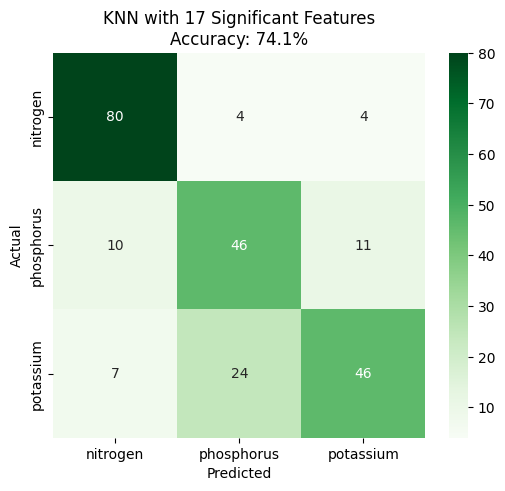

In [ ]:
# ============================================================
# CELL 12: RETAIN ONLY SIGNIFICANT FEATURES
# ============================================================

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get significant features from FSMR results
sig_features = fsmr_results[fsmr_results['Significant']]['Feature'].tolist()

print("=" * 60)
print("RETRAINING WITH SIGNIFICANT FEATURES ONLY")
print("=" * 60)
print(f"Original features: {len(feature_cols)}")
print(f"Significant features: {len(sig_features)}")
print(f"Removed features: {len(feature_cols) - len(sig_features)}")
print(f"\nRemoved: {[f for f in feature_cols if f not in sig_features]}")

# Prepare data with only significant features
X_train_sig = train_df[sig_features].values.astype(float)
X_test_sig = test_df[sig_features].values.astype(float)

# Handle any NaN/Inf (should be clean already)
X_train_sig = np.nan_to_num(X_train_sig, nan=0.0, posinf=999999, neginf=-999999)
X_test_sig = np.nan_to_num(X_test_sig, nan=0.0, posinf=999999, neginf=-999999)

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_sig)
X_test_scaled = scaler.transform(X_test_sig)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predict
y_pred = knn.predict(X_test_scaled)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("\n" + "=" * 60)
print(f"KNN Accuracy (significant features only): {accuracy*100:.1f}%")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.title(f'KNN with {len(sig_features)} Significant Features\nAccuracy: {accuracy*100:.1f}%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# ============================================================
# CELL A: IMPROVED REGION DETECTION
# ============================================================

import cv2
import numpy as np

def get_leaf_regions(img_rgb):
    """
    Find actual leaf tip, base, and margins using contours.
    """
    h, w = img_rgb.shape[:2]
    
    # Convert to grayscale and threshold to find leaf
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 60, 255, cv2.THRESH_BINARY)
    
    # Find largest contour (should be the leaf)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    
    leaf_contour = max(contours, key=cv2.contourArea)
    
    # Find extreme points
    topmost = tuple(leaf_contour[leaf_contour[:, :, 1].argmin()][0])
    bottommost = tuple(leaf_contour[leaf_contour[:, :, 1].argmax()][0])
    leftmost = tuple(leaf_contour[leaf_contour[:, :, 0].argmin()][0])
    rightmost = tuple(leaf_contour[leaf_contour[:, :, 0].argmax()][0])
    
    # Tip is the topmost point (lowest y)
    tip_y = topmost[1]
    
    # Base is bottommost (highest y)
    base_y = bottommost[1]
    
    # Margins are leftmost and rightmost
    left_x = leftmost[0]
    right_x = rightmost[0]
    
    # Define regions as percentages of actual leaf dimensions
    tip_height = int((base_y - tip_y) * 0.15)  # Top 15% of leaf
    margin_width = int((right_x - left_x) * 0.08)  # Outer 8%
    
    regions = {
        'tip_region': (tip_y, tip_y + tip_height, left_x, right_x),
        'base_region': (base_y - tip_height, base_y, left_x, right_x),
        'left_margin': (tip_y, base_y, left_x, left_x + margin_width),
        'right_margin': (tip_y, base_y, right_x - margin_width, right_x),
        'center_region': (tip_y + tip_height, base_y - tip_height, 
                          left_x + margin_width, right_x - margin_width)
    }
    
    return regions

# Test on one image
regions = get_leaf_regions(img_rgb)
print("Region detection test complete")

Region detection test complete


In [ ]:
# ============================================================
# CELL B: IMPROVED TIP YELLOWING
# ============================================================

def extract_tip_yellowing_improved(img_rgb):
    """
    Measure yellow specifically in the actual leaf tip.
    """
    regions = get_leaf_regions(img_rgb)
    if regions is None:
        return {'tip_yellowing': 0}
    
    tip_y1, tip_y2, tip_x1, tip_x2 = regions['tip_region']
    
    # Extract tip region
    tip_region = img_rgb[tip_y1:tip_y2, tip_x1:tip_x2]
    
    R = tip_region[:, :, 0].astype(float)
    G = tip_region[:, :, 1].astype(float)
    B = tip_region[:, :, 2].astype(float)
    
    # Yellow detection (improved thresholds)
    yellow_mask = (R > 120) & (G > 120) & (B < 90) & (R > B + 30) & (G > B + 30)
    
    total_pixels = R.size
    yellow_pixels = np.sum(yellow_mask)
    
    return {
        'tip_yellowing': yellow_pixels / total_pixels if total_pixels > 0 else 0
    }

# Test
tip_features = extract_tip_yellowing_improved(img_rgb)
print(f"Improved tip yellowing: {tip_features['tip_yellowing']:.4f}")

Improved tip yellowing: 0.0027


In [ ]:
# ============================================================
# CELL C: IMPROVED MARGIN BROWNING
# ============================================================

def extract_margin_browning_improved(img_rgb):
    """
    Measure brown specifically along actual leaf margins.
    """
    regions = get_leaf_regions(img_rgb)
    if regions is None:
        return {'margin_browning': 0}
    
    # Get left and right margin regions
    l_y1, l_y2, l_x1, l_x2 = regions['left_margin']
    r_y1, r_y2, r_x1, r_x2 = regions['right_margin']
    
    left_margin = img_rgb[l_y1:l_y2, l_x1:l_x2]
    right_margin = img_rgb[r_y1:r_y2, r_x1:r_x2]
    
    def brown_percentage(region):
        if region.size == 0:
            return 0
        R = region[:, :, 0].astype(float)
        G = region[:, :, 1].astype(float)
        B = region[:, :, 2].astype(float)
        brown_mask = (R > 70) & (R < 160) & (G > 40) & (G < 110) & (B > 10) & (B < 70) & (R > G) & (G > B)
        return np.sum(brown_mask) / region.size
    
    left_brown = brown_percentage(left_margin)
    right_brown = brown_percentage(right_margin)
    
    return {
        'margin_browning': (left_brown + right_brown) / 2
    }

# Test
margin_features = extract_margin_browning_improved(img_rgb)
print(f"Improved margin browning: {margin_features['margin_browning']:.4f}")

Improved margin browning: 0.0051


In [44]:
# ============================================================
# CELL D: UPDATED MASTER FEATURE EXTRACTOR
# ============================================================
# ============================================================
# FIX: UPDATED extract_from_folder FUNCTION
# ============================================================

def extract_from_folder(folder_path, label, feature_func, limit=None):
    """
    Extract features from all images in a folder using the specified feature function.
    """
    data = []
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if limit:
        files = files[:limit]
        print(f"  Processing {len(files)} images from {label}...")
    else:
        print(f"  Processing all {len(files)} images from {label}...")
    
    for i, f in enumerate(files):
        if (i + 1) % 50 == 0:
            print(f"    {i + 1}/{len(files)}...")
        
        features = feature_func(os.path.join(folder_path, f))
        if features:
            features['label'] = label
            features['filename'] = f
            data.append(features)
    
    return data
# ============================================================
# CELL D (FIXED): UPDATED MASTER FEATURE EXTRACTOR
# ============================================================

def extract_all_features_improved(image_path):
    """
    Extract all features with improved region detection.
    """
    img = cv2.imread(image_path)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    features = {}
    
    # Original color features
    features.update(extract_color_features(img_rgb))
    
    # Improved spatial features
    tip_features = extract_tip_yellowing_improved(img_rgb)
    if tip_features:
        features.update(tip_features)
    
    margin_features = extract_margin_browning_improved(img_rgb)
    if margin_features:
        features.update(margin_features)
    
    # Original texture/shape features
    texture_features = extract_texture_shape_features(img_rgb)
    if texture_features:
        features.update(texture_features)
    
    return features

In [46]:
# ============================================================
# CELL E (FIXED): RE-EXTRACT ALL FEATURES
# ============================================================

# Re-extract training features
print("=" * 60)
print("RE-EXTRACTING TRAINING FEATURES (IMPROVED)")
print("=" * 60)

train_data_improved = []
train_data_improved.extend(extract_from_folder(TRAIN_N_PATH, 'nitrogen', extract_all_features_improved))
train_data_improved.extend(extract_from_folder(TRAIN_P_PATH, 'phosphorus', extract_all_features_improved))
train_data_improved.extend(extract_from_folder(TRAIN_K_PATH, 'potassium', extract_all_features_improved))

print("\n" + "=" * 60)
print("RE-EXTRACTING TESTING FEATURES (IMPROVED)")
print("=" * 60)

test_data_improved = []
test_data_improved.extend(extract_from_folder(TEST_N_PATH, 'nitrogen', extract_all_features_improved))
test_data_improved.extend(extract_from_folder(TEST_P_PATH, 'phosphorus', extract_all_features_improved))
test_data_improved.extend(extract_from_folder(TEST_K_PATH, 'potassium', extract_all_features_improved))

# Create new DataFrames
train_df_new = pd.DataFrame(train_data_improved)
test_df_new = pd.DataFrame(test_data_improved)

print("\n" + "=" * 60)
print("EXTRACTION COMPLETE")
print("=" * 60)
print(f"Training samples: {len(train_df_new)}")
print(f"Testing samples: {len(test_df_new)}")
print(f"Features per image: {len([c for c in train_df_new.columns if c not in ['label', 'filename']])}")

RE-EXTRACTING TRAINING FEATURES (IMPROVED)
  Processing all 352 images from nitrogen...
    50/352...
    100/352...
    150/352...
    200/352...
    250/352...
    300/352...
    350/352...
  Processing all 266 images from phosphorus...
    50/266...
    100/266...
    150/266...
    200/266...
    250/266...
  Processing all 306 images from potassium...
    50/306...
    100/306...
    150/306...
    200/306...
    250/306...
    300/306...

RE-EXTRACTING TESTING FEATURES (IMPROVED)
  Processing all 88 images from nitrogen...
    50/88...
  Processing all 67 images from phosphorus...
    50/67...
  Processing all 77 images from potassium...
    50/77...

EXTRACTION COMPLETE
Training samples: 924
Testing samples: 232
Features per image: 18


In [47]:
# ============================================================
# CELL F: RETRAIN KNN WITH IMPROVED FEATURES
# ============================================================

# Prepare features
feature_cols_new = [c for c in train_df_new.columns if c not in ['label', 'filename']]
X_train_new = train_df_new[feature_cols_new].values.astype(float)
y_train_new = train_df_new['label'].values
X_test_new = test_df_new[feature_cols_new].values.astype(float)
y_test_new = test_df_new['label'].values

# Handle NaN/Inf
X_train_new = np.nan_to_num(X_train_new, nan=0.0, posinf=999999, neginf=-999999)
X_test_new = np.nan_to_num(X_test_new, nan=0.0, posinf=999999, neginf=-999999)

# Scale
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_new)
X_test_scaled = scaler.transform(X_test_new)

# Train
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_new)

# Predict
y_pred_new = knn.predict(X_test_scaled)

# Evaluate
accuracy_new = accuracy_score(y_test_new, y_pred_new)
print("=" * 60)
print(f"IMPROVED KNN Accuracy: {accuracy_new*100:.1f}%")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_new))

# Compare with previous
print("\n" + "=" * 60)
print("COMPARISON: Before vs After")
print("=" * 60)
print(f"Previous Accuracy: 74.1%")
print(f"Improved Accuracy: {accuracy_new*100:.1f}%")
print(f"Change: {(accuracy_new - 0.741)*100:+.1f}%")

IMPROVED KNN Accuracy: 81.0%

Classification Report:
              precision    recall  f1-score   support

    nitrogen       0.90      0.90      0.90        88
  phosphorus       0.70      0.81      0.75        67
   potassium       0.82      0.71      0.76        77

    accuracy                           0.81       232
   macro avg       0.81      0.81      0.80       232
weighted avg       0.82      0.81      0.81       232


COMPARISON: Before vs After
Previous Accuracy: 74.1%
Improved Accuracy: 81.0%
Change: +6.9%


In [52]:
import joblib


# feature_cols_new should still be defined from your KNN training
# If not, redefine it:
feature_cols_new = [c for c in train_df_new.columns if c not in ['label', 'filename']]

# Save it
joblib.dump(feature_cols_new, 'models/knn_feature_columns.pkl')

print(f"Saved {len(feature_cols_new)} feature columns")
print("First 5 columns:", feature_cols_new[:5])

# Save the trained KNN model
joblib.dump(knn, 'models/knn_leaf_model.pkl')

# Save the scaler (CRITICAL - must use same scaler for new predictions)
joblib.dump(scaler, 'models/knn_scaler.pkl')

# Save feature names
joblib.dump(feature_cols_new, 'models/knn_features.pkl')
print("All models saved to models/ folder")


Saved 18 feature columns
First 5 columns: ['mean_green', 'yellow_percentage', 'mean_red', 'purple_tint', 'brown_percentage']
All models saved to models/ folder
